Cod relog

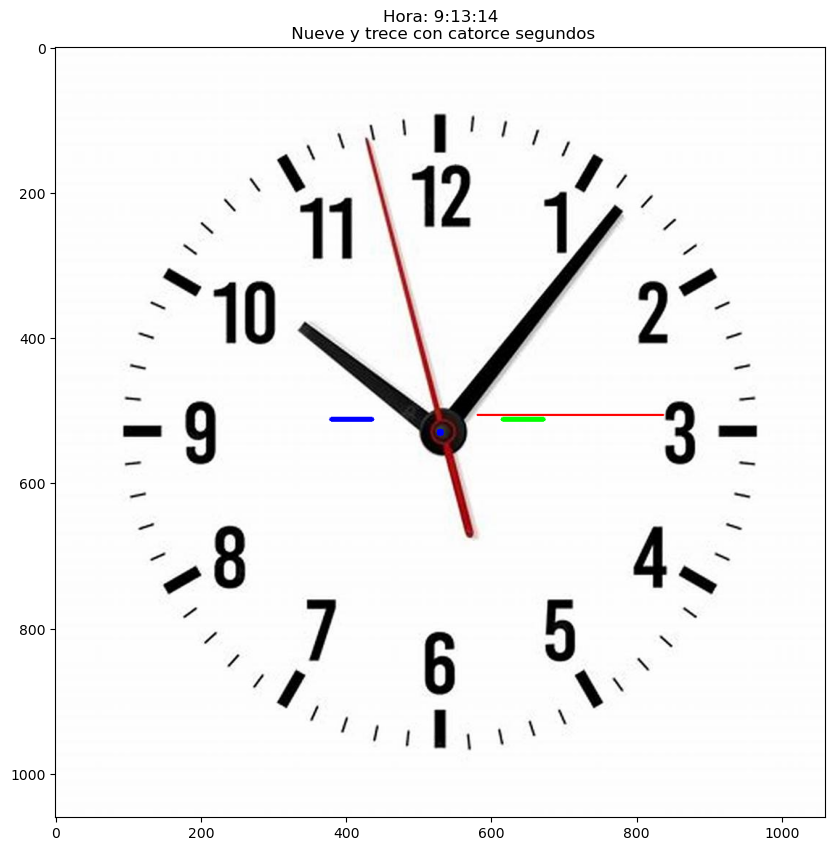

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def numero_a_palabra(numero):
    palabras = ["cero", "una", "dos", "tres", "cuatro", "cinco", "seis", "siete", "ocho", "nueve", "diez",
                "once", "doce", "trece", "catorce", "quince", "dieciséis", "diecisiete", "dieciocho",
                "diecinueve", "veinte", "veintiuno", "veintidós", "veintitrés", "veinticuatro",
                "veinticinco", "veintiséis", "veintisiete", "veintiocho", "veintinueve"]
    if numero < 30:
        return palabras[numero]
    elif numero < 60:
        decenas = ["treinta", "cuarenta", "cincuenta"]
        base = decenas[(numero // 10) - 3]
        resto = numero % 10
        if resto == 0:
            return base
        else:
            return f"{base} y {palabras[resto]}"
    else:
        return str(numero)
    
def hora_en_palabras(hora, minutos):
    en_punto = ["en punto", "y cinco", "y diez", "y cuarto", "y veinte", "y veinticinco", "y media"]
    menos = ["menos veinticinco", "menos veinte", "menos cuarto", "menos diez", "menos cinco"]

    if minutos == 0:
        return f"{numero_a_palabra(hora)} en punto"
    elif minutos == 15:
        return f"{numero_a_palabra(hora)} y cuarto"
    elif minutos == 30:
        return f"{numero_a_palabra(hora)} y media"
    elif minutos == 45:
        siguiente_hora = (hora + 1) % 12 or 12
        return f"{numero_a_palabra(siguiente_hora)} menos cuarto"
    elif 1 <= minutos < 30:
        return f"{numero_a_palabra(hora)} y {numero_a_palabra(minutos)}"
    elif 31 <= minutos < 60:
        siguiente_hora = (hora + 1) % 12 or 12
        return f"{numero_a_palabra(siguiente_hora)} menos {numero_a_palabra(60 - minutos)}"
    else:
        return f"{numero_a_palabra(hora)} y {numero_a_palabra(minutos)}"



imagen_bgr = cv2.imread('RELOJ4.jpg')
imagen_rgb = cv2.cvtColor(imagen_bgr,cv2.COLOR_BGR2RGB)

gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
gris = cv2.GaussianBlur(gris, (5, 5), 1)
gris = cv2.equalizeHist(gris)

imgNorm=cv2.normalize(gris,None,0,255,cv2.NORM_MINMAX).astype(np.uint8)

bordes = cv2.Canny(imgNorm, 50, 150)

# Detección de líneas
lineas = cv2.HoughLinesP(bordes, 1, np.pi/180, threshold=80, minLineLength=50, maxLineGap=10)


centro_x = imagen_bgr.shape[1] // 2
centro_y = imagen_bgr.shape[0] // 2

def calcular_angulo(x1, y1, x2, y2):
    dist1 = np.hypot(x1 - centro_x, y1 - centro_y)
    dist2 = np.hypot(x2 - centro_x, y2 - centro_y)
    if dist1 > dist2:
        dx = x1 - centro_x
        dy = centro_y - y1
    else:
        dx = x2 - centro_x
        dy = centro_y - y2
    angulo = np.degrees(np.arctan2(dy, dx))
    angulo = (90 - angulo) % 360
    return angulo

manecillas = []
if lineas is not None:
    for linea in lineas:
        x1, y1, x2, y2 = linea[0]
        longitud = np.hypot(x2 - x1, y2 - y1)
        distancia_centro = min(np.hypot(x1 - centro_x, y1 - centro_y),np.hypot(x2 - centro_x, y2 - centro_y))
        # LINEAS CENTRO
        if distancia_centro < 100 and 30 < longitud < 300:
            angulo = calcular_angulo(x1, y1, x2, y2)
            manecillas.append({
                'puntos': (x1, y1, x2, y2),
                'longitud': longitud,
                'angulo': angulo
            })

if len(manecillas) >= 3:
     # CORTO LARGO
    manecillas.sort(key=lambda x: x['longitud'])
    horario = manecillas[3]
    minutero = manecillas[2]
    segundero = manecillas[-5]
    
    hora = int((horario['angulo'] / 30) % 12)
    minutos = int((minutero['angulo'] / 6) % 60)
    segundos = int((segundero['angulo'] / 6) % 60)

    fraccion_hora = (horario['angulo'] / 30) % 12
    if abs(fraccion_hora - hora) > 0.5:
        hora = (hora + 1) % 12

    imagen_resultado = imagen_rgb.copy()
    cv2.circle(imagen_resultado, (centro_x, centro_y), 5, (0, 0, 255), -1)
    cv2.line(imagen_resultado, (horario['puntos'][0], horario['puntos'][1]), (horario['puntos'][2], horario['puntos'][3]), (0, 0, 255), 5)  # hora azul
    cv2.line(imagen_resultado, (minutero['puntos'][0], minutero['puntos'][1]), (minutero['puntos'][2], minutero['puntos'][3]), (0, 255, 0), 5)  # minutos verde
    cv2.line(imagen_resultado, (segundero['puntos'][0], segundero['puntos'][1]), (segundero['puntos'][2], segundero['puntos'][3]), (255, 0, 0), 2)  # segundos rojo

    plt.figure(figsize=(10, 10))
    plt.imshow(imagen_resultado)
    hora_literal = hora_en_palabras(hora, minutos)
    segundos_literal = f"{numero_a_palabra(segundos)} segundos"

    plt.title(f'Hora: {hora}:{minutos:02d}:{segundos:02d}\n {hora_literal.capitalize()} con {segundos_literal}')
    plt.show()